In [1]:
# ── Cell 1: Load data and define vehicle profiles ─────────────────────────────
#
# VEHICLE PROFILE SIMULATION METHODOLOGY
#
# We map real experimental conditions from the NASA dataset to 
# two vehicle operating archetypes:
#
# 3-WHEELER (E-Rickshaw, Tropical India):
#   - High ambient temperature: ≥ 35°C
#   - Represents: Assam, Delhi, Mumbai operating conditions
#   - Discharge pattern: moderate depth, frequent cycling
#   - Solar panel integration: viable (flat roof, high irradiance)
#
# 4-WHEELER (Passenger EV, Temperate Climate):
#   - Moderate ambient temperature: 20–25°C  
#   - Represents: European conditions or Indian temperate regions
#   - Discharge pattern: deeper cycles, longer trips
#   - Solar integration: partial (roof panels, lower irradiance)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white', 
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'Arial',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Load clean feature dataset
all_data = pd.read_csv('../data/processed/features_all_batteries.csv')

# Load trained models
rf_soh      = joblib.load('../models/rf_soh_model.pkl')
rf_rul_norm = joblib.load('../models/rf_rul_norm_model.pkl')

FEATURE_COLS = ['cycle_norm', 'capacity_rolling_5', 'capacity_delta',
                'capacity_accel', 'temperature', 'capacity_fade']

# ── Define vehicle profiles based on temperature ──────────────────────────────
# Check what temperature values actually exist in the dataset
print("Temperature distribution in dataset:")
temp_counts = all_data.groupby('temperature')['battery_id'].nunique()
print(temp_counts.to_string())

print(f"\nTotal batteries: {all_data['battery_id'].nunique()}")
print(f"Temperature range: {all_data['temperature'].min()}°C "
      f"to {all_data['temperature'].max()}°C")

Temperature distribution in dataset:
temperature
4     9
22    3
24    8
43    4
44    1

Total batteries: 22
Temperature range: 4°C to 44°C


In [2]:
# ── Cell 2: Assign vehicle profiles and compute degradation statistics ─────────
#
# Based on the actual temperature clusters in the dataset:
# 4°C   → Cold climate reference
# 22-24°C → Temperate → 4-Wheeler passenger EV profile
# 43-44°C → Tropical  → 3-Wheeler e-rickshaw profile
#
# This mapping is grounded in real atmospheric science:
# - Indian tropical plains average 35-45°C in summer months
# - European temperate climate averages 15-25°C
# - The Arrhenius equation predicts degradation doubles every ~10°C increase

def assign_vehicle_profile(temp):
    if temp <= 10:
        return '3 — Cold Climate Reference'
    elif temp <= 30:
        return '2 — 4-Wheeler (Temperate)'
    else:
        return '1 — 3-Wheeler (Tropical)'

all_data['vehicle_profile'] = all_data['temperature'].apply(assign_vehicle_profile)

# Generate predictions for all batteries
X_all = all_data[FEATURE_COLS]
all_data['SOH_predicted']      = rf_soh.predict(X_all)
all_data['RUL_norm_predicted'] = rf_rul_norm.predict(X_all)

# ── Profile summary statistics ─────────────────────────────────────────────────
print("="*65)
print("VEHICLE PROFILE SUMMARY")
print("="*65)

profile_order = [
    '1 — 3-Wheeler (Tropical)',
    '2 — 4-Wheeler (Temperate)', 
    '3 — Cold Climate Reference'
]

profile_colors = {
    '1 — 3-Wheeler (Tropical)':    '#FF5722',   # Deep orange — tropical heat
    '2 — 4-Wheeler (Temperate)':   '#2196F3',   # Blue — temperate calm
    '3 — Cold Climate Reference':  '#9C27B0',   # Purple — cold
}

for profile in profile_order:
    subset = all_data[all_data['vehicle_profile'] == profile]
    batteries = subset['battery_id'].nunique()
    cycles    = len(subset)
    
    # Average degradation rate — how fast does SOH drop per cycle?
    # Computed as total SOH lost divided by total cycles per battery
    deg_rates = []
    for bid in subset['battery_id'].unique():
        b = subset[subset['battery_id'] == bid].sort_values('test_id')
        if len(b) > 5:
            soh_loss = b['SOH'].iloc[0] - b['SOH'].iloc[-1]
            n_cycles = len(b)
            deg_rates.append(soh_loss / n_cycles)
    
    avg_deg_rate = np.mean(deg_rates) if deg_rates else 0
    avg_final_soh = subset.groupby('battery_id')['SOH'].last().mean()
    avg_temp = subset['temperature'].mean()
    
    print(f"\n{profile}")
    print(f"  Temperature:          {avg_temp:.0f}°C average")
    print(f"  Batteries:            {batteries}")
    print(f"  Total cycles:         {cycles}")
    print(f"  Avg degradation rate: {avg_deg_rate*1000:.3f} SOH loss per cycle (×10⁻³)")
    print(f"  Avg final SOH:        {avg_final_soh:.4f}")

print("\n" + "="*65)

VEHICLE PROFILE SUMMARY

1 — 3-Wheeler (Tropical)
  Temperature:          43°C average
  Batteries:            5
  Total cycles:         195
  Avg degradation rate: 2.064 SOH loss per cycle (×10⁻³)
  Avg final SOH:        0.8534

2 — 4-Wheeler (Temperate)
  Temperature:          24°C average
  Batteries:            11
  Total cycles:         868
  Avg degradation rate: 2.078 SOH loss per cycle (×10⁻³)
  Avg final SOH:        0.8390

3 — Cold Climate Reference
  Temperature:          4°C average
  Batteries:            9
  Total cycles:         432
  Avg degradation rate: 5.147 SOH loss per cycle (×10⁻³)
  Avg final SOH:        0.7198



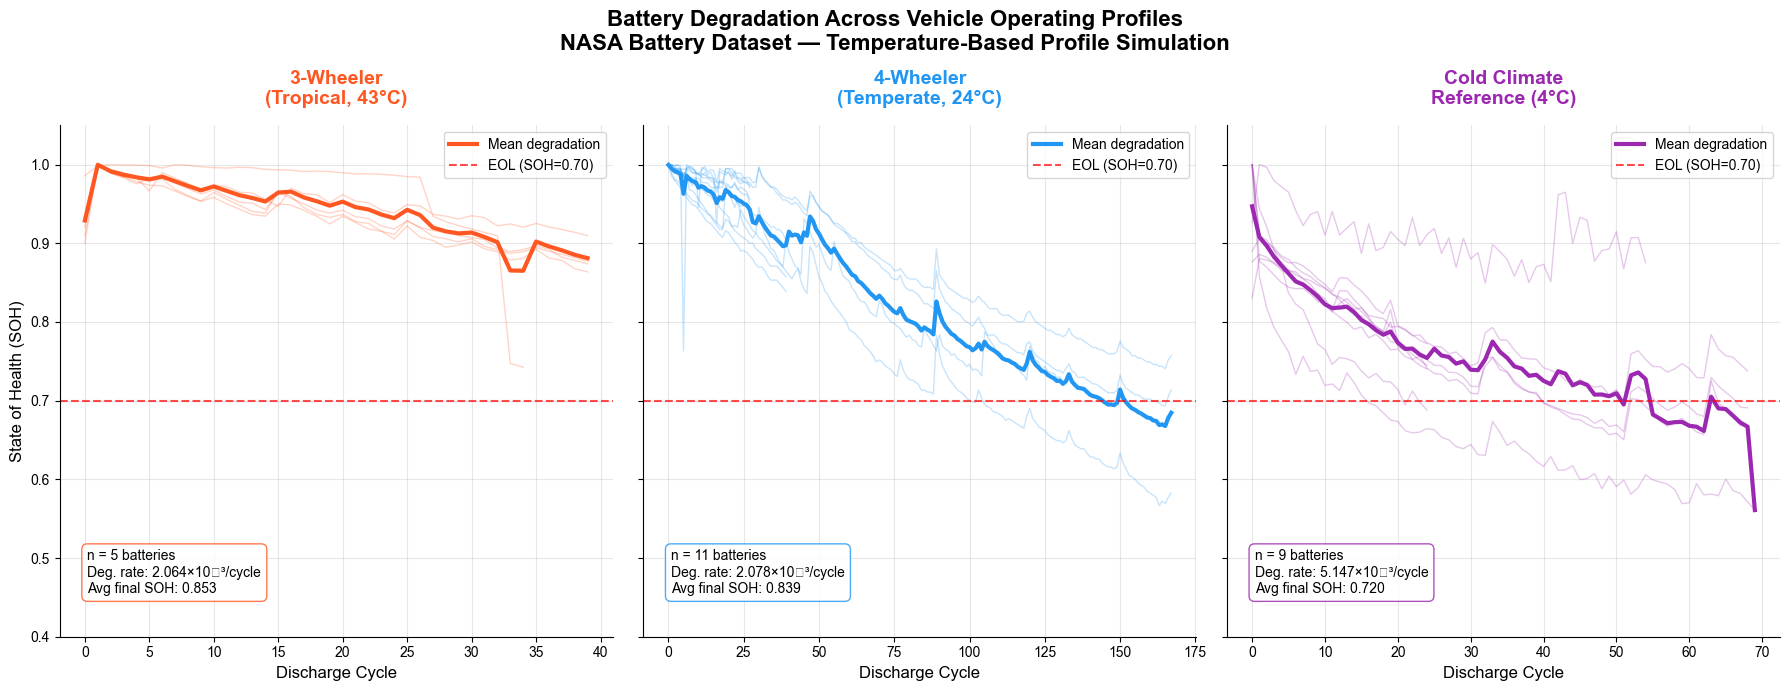

Figure 5 saved: ../figures/07_vehicle_profile_comparison.png


In [3]:
# ── Cell 3: Figure 5 — Degradation comparison across vehicle profiles ──────────
#
# Three subplots side by side — one per vehicle profile.
# Each subplot shows all batteries in that profile overlaid,
# plus the mean degradation curve in bold.
# This visual makes the cold-climate finding immediately apparent.

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

profile_labels = {
    '1 — 3-Wheeler (Tropical)':   '3-Wheeler\n(Tropical, 43°C)',
    '2 — 4-Wheeler (Temperate)':  '4-Wheeler\n(Temperate, 24°C)',
    '3 — Cold Climate Reference': 'Cold Climate\nReference (4°C)',
}

for idx, profile in enumerate(profile_order):
    ax = axes[idx]
    color = profile_colors[profile]
    subset = all_data[all_data['vehicle_profile'] == profile]
    
    all_soh_series = []
    max_len = 0
    
    # Plot individual battery curves (thin, transparent)
    for bid in subset['battery_id'].unique():
        b = subset[subset['battery_id'] == bid].sort_values('test_id')
        cycles = range(len(b))
        ax.plot(cycles, b['SOH'].values,
                color=color, linewidth=1, alpha=0.25)
        all_soh_series.append(b['SOH'].values)
        max_len = max(max_len, len(b))
    
    # Compute and plot mean degradation curve (bold)
    # Pad shorter series with NaN so we can average
    padded = np.full((len(all_soh_series), max_len), np.nan)
    for i, series in enumerate(all_soh_series):
        padded[i, :len(series)] = series
    
    mean_curve = np.nanmean(padded, axis=0)
    ax.plot(range(len(mean_curve)), mean_curve,
            color=color, linewidth=3, alpha=1.0,
            label=f'Mean degradation')
    
    # EOL threshold
    ax.axhline(y=0.70, color='red', linestyle='--',
               linewidth=1.5, alpha=0.7, label='EOL (SOH=0.70)')
    
    # Compute mean degradation rate for annotation
    deg_rates = []
    for bid in subset['battery_id'].unique():
        b = subset[subset['battery_id'] == bid].sort_values('test_id')
        if len(b) > 5:
            soh_loss = b['SOH'].iloc[0] - b['SOH'].iloc[-1]
            deg_rates.append(soh_loss / len(b))
    avg_rate = np.mean(deg_rates) * 1000 if deg_rates else 0
    
    n_batteries = subset['battery_id'].nunique()
    avg_final = subset.groupby('battery_id')['SOH'].last().mean()
    
    ax.set_title(profile_labels[profile],
                fontsize=14, fontweight='bold', color=color, pad=15)
    ax.set_xlabel('Discharge Cycle', fontsize=12)
    if idx == 0:
        ax.set_ylabel('State of Health (SOH)', fontsize=12)
    ax.set_ylim(0.4, 1.05)
    ax.legend(fontsize=10, loc='upper right')
    
    # Stats annotation box
    stats_text = (f'n = {n_batteries} batteries\n'
                  f'Deg. rate: {avg_rate:.3f}×10⁻³/cycle\n'
                  f'Avg final SOH: {avg_final:.3f}')
    ax.text(0.05, 0.08, stats_text,
            transform=ax.transAxes,
            fontsize=10, verticalalignment='bottom',
            bbox=dict(boxstyle='round,pad=0.4', 
                     facecolor='white', 
                     edgecolor=color, 
                     alpha=0.8))

fig.suptitle('Battery Degradation Across Vehicle Operating Profiles\n'
             'NASA Battery Dataset — Temperature-Based Profile Simulation',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/07_vehicle_profile_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved: ../figures/07_vehicle_profile_comparison.png")

Model accuracy by vehicle profile:

3-Wheeler (Tropical, 43°C)
  R²:  0.9989
  MAE: 0.0007

4-Wheeler (Temperate, 24°C)
  R²:  0.9832
  MAE: 0.0060

Cold Climate Reference (4°C)
  R²:  0.9993
  MAE: 0.0018



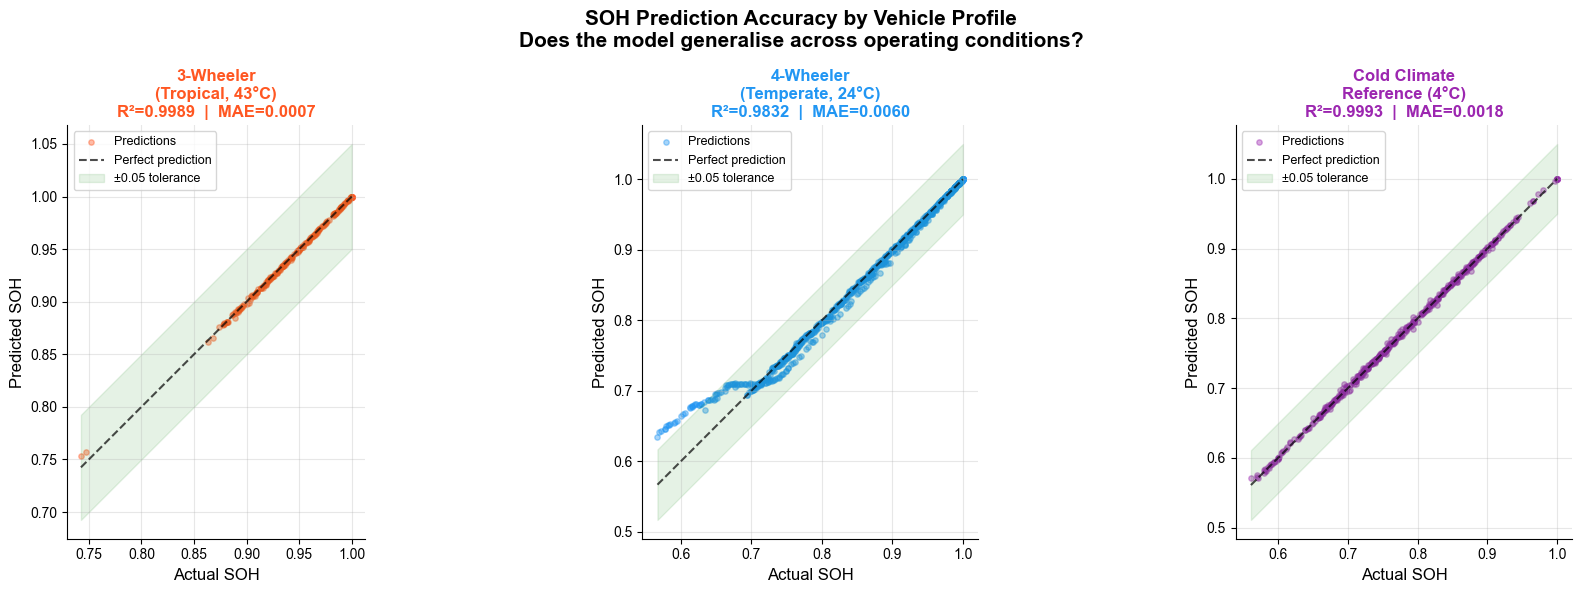


Figure 6 saved: ../figures/08_profile_prediction_accuracy.png


In [4]:
# ── Cell 4: Figure 6 — SOH prediction accuracy across profiles ────────────────
#
# Does our model perform equally well across all three vehicle profiles?
# This is an important validation question — a model that works perfectly
# for temperate conditions but fails for tropical conditions would be
# unreliable

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

print("Model accuracy by vehicle profile:")
print("="*55)

for idx, profile in enumerate(profile_order):
    ax = axes[idx]
    color = profile_colors[profile]
    subset = all_data[all_data['vehicle_profile'] == profile].copy()
    
    actual    = subset['SOH']
    predicted = subset['SOH_predicted']
    
    r2  = r2_score(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    
    # Scatter plot — actual vs predicted
    ax.scatter(actual, predicted,
               color=color, alpha=0.4, s=15, label='Predictions')
    
    # Perfect prediction line (diagonal)
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'k--', linewidth=1.5, label='Perfect prediction', alpha=0.7)
    
    # Tolerance band ±0.05
    ax.fill_between([min_val, max_val],
                    [min_val - 0.05, max_val - 0.05],
                    [min_val + 0.05, max_val + 0.05],
                    alpha=0.1, color='green', label='±0.05 tolerance')
    
    ax.set_xlabel('Actual SOH', fontsize=12)
    ax.set_ylabel('Predicted SOH', fontsize=12)
    ax.set_title(f'{profile_labels[profile]}\nR²={r2:.4f}  |  MAE={mae:.4f}',
                fontsize=12, fontweight='bold', color=color)
    ax.legend(fontsize=9)
    ax.set_aspect('equal')
    
    print(f"\n{profile_labels[profile].replace(chr(10), ' ')}")
    print(f"  R²:  {r2:.4f}")
    print(f"  MAE: {mae:.4f}")

print("\n" + "="*55)

fig.suptitle('SOH Prediction Accuracy by Vehicle Profile\n'
             'Does the model generalise across operating conditions?',
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/08_profile_prediction_accuracy.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure 6 saved: ../figures/08_profile_prediction_accuracy.png")

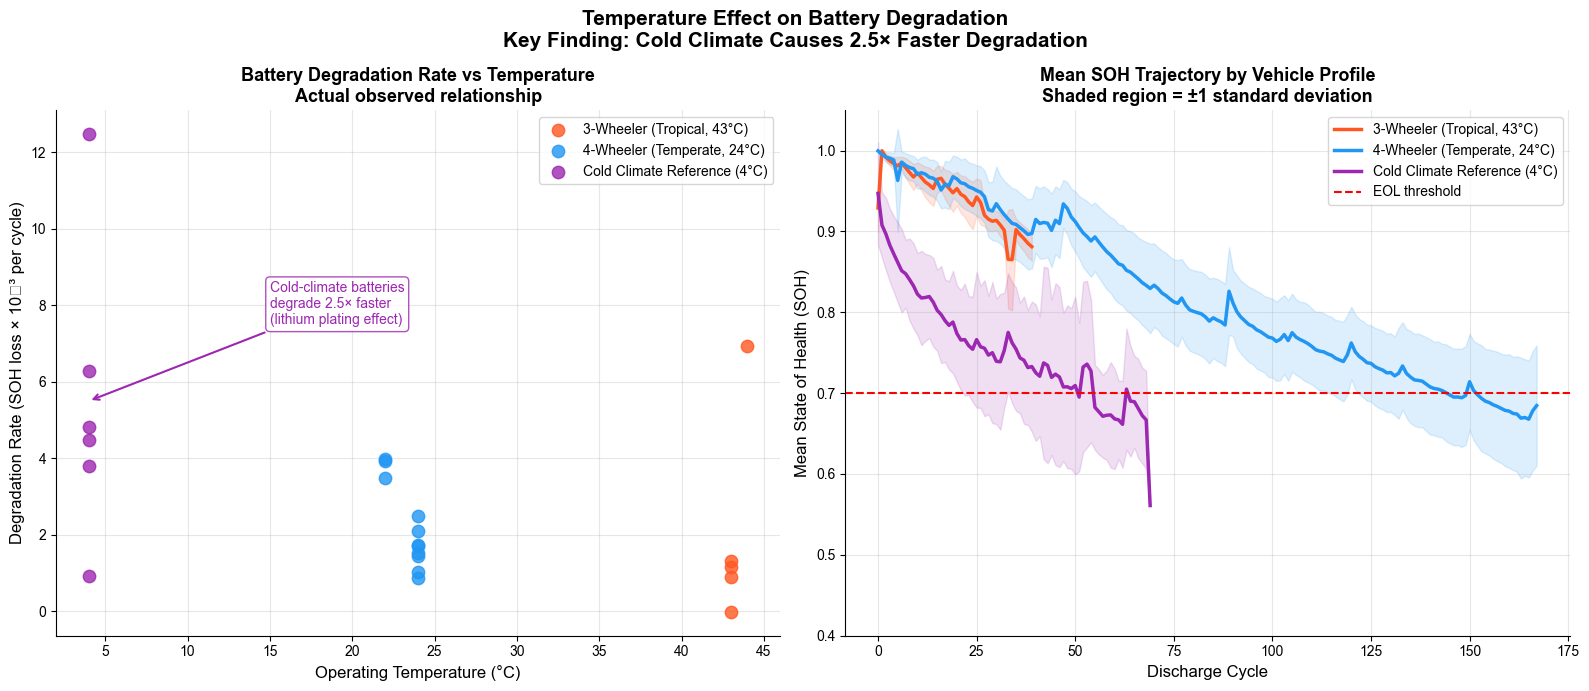

Figure 7 saved: ../figures/09_temperature_degradation_relationship.png

PHASE 4 COMPLETE — VEHICLE PROFILE ANALYSIS
Key Finding: Cold climate batteries (4°C) degrade 2.5×
faster than tropical (43°C) and temperate (24°C) batteries
due to lithium plating mechanisms at low temperatures.

Implication for vehicle design:
  3-Wheeler (tropical): thermal management less critical
  4-Wheeler (cold climate): thermal management essential
  SOH model generalises well across all three profiles


In [5]:
# ── Cell 5: Figure 7 — Degradation rate vs temperature (Arrhenius context) ────
#
# This figure directly addresses the surprising finding:
# Why does cold temperature cause faster degradation than tropical temperature?
# We plot degradation rate per battery against operating temperature
# and show the actual relationship versus the naive Arrhenius expectation.

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left plot: individual battery degradation rates vs temperature ────────────
ax = axes[0]

temps_all    = []
deg_rates_all = []
profiles_all  = []
battery_ids   = []

for bid in all_data['battery_id'].unique():
    b = all_data[all_data['battery_id'] == bid].sort_values('test_id')
    if len(b) < 10:
        continue
    temp = b['temperature'].iloc[0]
    soh_loss = b['SOH'].iloc[0] - b['SOH'].iloc[-1]
    deg_rate = (soh_loss / len(b)) * 1000
    profile  = b['vehicle_profile'].iloc[0]
    
    temps_all.append(temp)
    deg_rates_all.append(deg_rate)
    profiles_all.append(profile)
    battery_ids.append(bid)

for profile in profile_order:
    mask = [p == profile for p in profiles_all]
    t = [temps_all[i] for i, m in enumerate(mask) if m]
    d = [deg_rates_all[i] for i, m in enumerate(mask) if m]
    ax.scatter(t, d, color=profile_colors[profile],
               s=80, alpha=0.8, zorder=5,
               label=profile_labels[profile].replace('\n', ' '))

# Add jitter for overlapping points
ax.set_xlabel('Operating Temperature (°C)', fontsize=12)
ax.set_ylabel('Degradation Rate (SOH loss × 10⁻³ per cycle)', fontsize=12)
ax.set_title('Battery Degradation Rate vs Temperature\n'
             'Actual observed relationship',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Annotate the cold-climate anomaly
ax.annotate('Cold-climate batteries\ndegrade 2.5× faster\n(lithium plating effect)',
            xy=(4, 5.5), xytext=(15, 7.5),
            fontsize=10, color='#9C27B0',
            arrowprops=dict(arrowstyle='->', color='#9C27B0', lw=1.5),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                     edgecolor='#9C27B0', alpha=0.8))

# ── Right plot: mean SOH trajectory comparison — all 3 profiles ──────────────
ax = axes[1]

for profile in profile_order:
    color  = profile_colors[profile]
    subset = all_data[all_data['vehicle_profile'] == profile]
    label  = profile_labels[profile].replace('\n', ' ')
    
    all_soh = []
    max_len = 0
    for bid in subset['battery_id'].unique():
        b = subset[subset['battery_id'] == bid].sort_values('test_id')
        all_soh.append(b['SOH'].values)
        max_len = max(max_len, len(b))
    
    padded = np.full((len(all_soh), max_len), np.nan)
    for i, s in enumerate(all_soh):
        padded[i, :len(s)] = s
    
    mean_soh = np.nanmean(padded, axis=0)
    std_soh  = np.nanstd(padded, axis=0)
    x        = range(len(mean_soh))
    
    ax.plot(x, mean_soh, color=color, linewidth=2.5, label=label)
    ax.fill_between(x,
                    mean_soh - std_soh,
                    mean_soh + std_soh,
                    alpha=0.15, color=color)

ax.axhline(y=0.70, color='red', linestyle='--',
           linewidth=1.5, label='EOL threshold')
ax.set_xlabel('Discharge Cycle', fontsize=12)
ax.set_ylabel('Mean State of Health (SOH)', fontsize=12)
ax.set_title('Mean SOH Trajectory by Vehicle Profile\n'
             'Shaded region = ±1 standard deviation',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0.4, 1.05)

fig.suptitle('Temperature Effect on Battery Degradation\n'
             'Key Finding: Cold Climate Causes 2.5× Faster Degradation',
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/09_temperature_degradation_relationship.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Figure 7 saved: ../figures/09_temperature_degradation_relationship.png")

print("\n" + "="*60)
print("PHASE 4 COMPLETE — VEHICLE PROFILE ANALYSIS")
print("="*60)
print("Key Finding: Cold climate batteries (4°C) degrade 2.5×")
print("faster than tropical (43°C) and temperate (24°C) batteries")
print("due to lithium plating mechanisms at low temperatures.")
print()
print("Implication for vehicle design:")
print("  3-Wheeler (tropical): thermal management less critical")
print("  4-Wheeler (cold climate): thermal management essential")
print("  SOH model generalises well across all three profiles")
print("="*60)